# Ground Condition Predictor — RF vs XGBoost

**Pipeline overview:**
1. **Data loading** — original project CSVs + new REC_*.csv files with embedded surface markers
2. **Surface labelling** — `x` markers in the CSV columns define surface segment start points
3. **Surface mapping** — raw labels normalised to 3 classes: `grass`, `brick`, `concrete`
4. **Step detection** — Savitzky-Golay smoothed heel pressure peak-finding
5. **Feature extraction** — per-step biomechanical features (impact, loading rate, midstance, pressure stats)
6. **Model comparison** — Random Forest vs XGBoost, side-by-side 5-fold CV
7. **Prediction** — classify steps from any new CSV using the best model

**Surface mapping applied:**

| Raw label | Mapped class |
|---|---|
| grass, compact ground, dirt | `grass` |
| brick | `brick` |
| concrete, asphalt, exposed aggregate | `concrete` |

## 0. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
import os

# ── Sensor groups (Stappone insole layout) ────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]
IMU_COLS         = ['accel_x', 'accel_y', 'accel_z',
                    'gyro_x', 'gyro_y', 'gyro_z',
                    'magn_x', 'magn_y', 'magn_z']

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

# ── Surface normalisation map ─────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass',
    'compact ground': 'grass',
    'dirt': 'grass',
    'brick': 'brick',
    'concrete': 'concrete',
    'asphalt': 'concrete',
    'exposed aggregate': 'concrete',
}

BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + [f'pressure_{i:02d}' for i in range(1, 13)]
)

SURFACE_COLORS = {
    'grass':    '#4CAF50',
    'brick':    '#E64A19',
    'concrete': '#607D8B',
    'unknown':  '#9E9E9E'
}

# ── Data paths ────────────────────────────────────────────────────────
# Original labelled project CSVs
ORIGINAL_CSVS = {
    'grass':    'grass_dry.csv',
    'brick':    'brick_dry.csv',
    'concrete': 'concrete_dry.csv',
}

# New REC_* files with embedded surface markers
REC_DIR = '.'   # ← Change to folder containing REC_*.csv files if needed

print('Ready.')

Ready.


## 1. Core Functions

In [3]:
def get_surface_cols(df):
    """Return columns in df that are surface marker columns (i.e. in SURFACE_MAP)."""
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """
    Parse the 'x' surface markers embedded in the CSV.
    Each 'x' mark indicates the START of that surface type.
    Returns a copy of df with a 'surface' column, rows without a label dropped.
    """
    surf_cols = get_surface_cols(df)
    if not surf_cols:
        return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    # Collect (row_index, mapped_surface) for every marker
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]:
            events.append((int(idx), SURFACE_MAP[col]))
    if not events:
        return None
    events.sort(key=lambda e: e[0])
    df['surface'] = None
    for i, (start_idx, surf) in enumerate(events):
        end_idx = events[i+1][0] if i+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = surf
    return df[df['surface'].notna()].copy()


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df, sensors=HEEL_SENSORS):
    """Return array of stance-peak indices from the smoothed summed heel signal."""
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in sensors if s in df.columns
    )
    n  = len(y_comb)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY:
        sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY + 3) % 2 == 0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def extract_step_features(df, surface_label='unknown', foot_label='unknown'):
    """
    For every detected step window compute biomechanical features.
    If df has a 'surface' column, the majority surface within each step window
    overrides surface_label.
    """
    df = df.copy().reset_index(drop=True)
    t        = df['time_sec'].values
    heel_sig = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y  = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    total_p  = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values

    peaks = find_step_windows(df)
    if len(peaks) < 2:
        return pd.DataFrame()

    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wtp=total_p[p1:p2]; wt=t[p1:p2]
        if len(wh) < MIN_DP:
            continue

        # Midstance
        c_loc = int(np.argmin(wh))
        diff  = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc = c_loc + int(np.argmin(diff))

        # Impact magnitude
        hw     = min(int(0.15 * SAMPLING_HZ), len(way) - 1)
        impact = float(np.max(np.abs(way[max(0, c_loc-hw):c_loc+hw+1])))

        # Loading rate
        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy  = pd.to_numeric(df[s], errors='coerce').fillna(0).values[p1:p2]
            hlo = int(np.argmin(sy))
            seg = sy[hlo:min(hlo+HILL_WIN, len(sy))]
            if len(seg) < 2: continue
            lp, _ = find_peaks(seg, prominence=1)
            hhi = lp[0] if len(lp) else int(np.argmax(seg[1:])) + 1
            rise = float(sy[hlo+hhi] - sy[hlo])
            dt   = hhi / SAMPLING_HZ
            if dt > 0 and rise > MIN_DP:
                lr_vals.append(rise / dt)
        lr = float(np.mean(lr_vals)) if lr_vals else 0.0

        # Determine surface label from within-step majority if available
        step_surf = surface_label
        if 'surface' in df.columns:
            step_surfs = df['surface'].iloc[p1:p2].dropna()
            if len(step_surfs):
                step_surf = step_surfs.mode()[0]

        row = {
            'foot': foot_label, 'step_id': i, 'surface': step_surf,
            'contact_time_sec': float(wt[0]) if len(wt) else 0.0,
            'stance_duration':  float(wt[-1]-wt[0]) if len(wt) > 1 else 0.0,
            'impact_mag':       impact,
            'loading_rate':     lr,
            'midstance_diff':   float(whn[m_loc]-wfn[m_loc]) if m_loc < len(whn) else 0.0,
            'heel_pmax':        float(np.max(wh)),
            'fore_pmax':        float(np.max(wf)),
            'total_pmax':       float(np.max(wtp)),
            'heel_mean':        float(np.mean(wh)),
            'fore_mean':        float(np.mean(wf)),
            'heel_fore_ratio':  float(np.mean(wh) / (np.mean(wf) + 1e-9)),
        }
        for s in ALL_SENSORS:
            if s in df.columns:
                seg_s = pd.to_numeric(df[s], errors='coerce').fillna(0).values[p1:p2]
                row[f'{s}_mean'] = float(np.mean(seg_s))
        rows.append(row)

    return pd.DataFrame(rows)


print('Core functions defined.')

Core functions defined.


## 2. Load & Label All Data

Two data sources are combined:
- **Original project CSVs** (`grass_dry.csv`, `brick_dry.csv`, `concrete_dry.csv`) — entire file is one surface
- **New REC_*.csv files** — surface segments defined by `x` markers in extra columns

In [4]:
all_frames = []

# ── 2a. Original project CSVs ─────────────────────────────────────────
print('Loading original project CSVs...')
for surface_label, csv_path in ORIGINAL_CSVS.items():
    if not os.path.exists(csv_path):
        print(f'  [SKIP] {csv_path} not found')
        continue
    raw = pd.read_csv(csv_path, low_memory=False)
    for sole_id, foot in [(1, 'right'), (2, 'left')]:
        sub = preprocess(raw[raw['sole_id'] == sole_id])
        feats = extract_step_features(sub, surface_label=surface_label, foot_label=foot)
        if len(feats):
            all_frames.append(feats)
            print(f'  {csv_path} [{foot}]: {len(feats)} steps')

# ── 2b. New REC_* files with embedded markers ─────────────────────────
print('\nLoading REC_* files...')
rec_files = sorted([f for f in os.listdir(REC_DIR)
                    if f.startswith('REC_') and f.endswith('.csv')])

for fname in rec_files:
    fpath = os.path.join(REC_DIR, fname)
    raw = pd.read_csv(fpath, low_memory=False)
    file_steps = 0
    for sole_id, foot in [(1, 'right'), (2, 'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        labelled = label_surface_segments(sub)
        if labelled is None or len(labelled) == 0:
            continue
        labelled = preprocess(labelled)
        feats = extract_step_features(labelled, foot_label=foot)
        if len(feats):
            all_frames.append(feats)
            file_steps += len(feats)
    print(f'  {fname}: {file_steps} steps')

# ── Combine ───────────────────────────────────────────────────────────
full_df = pd.concat(all_frames, ignore_index=True)
print(f'\nTotal steps: {len(full_df)}')
print('Surface distribution:')
print(full_df['surface'].value_counts().to_string())

Loading original project CSVs...
  grass_dry.csv [right]: 20 steps
  grass_dry.csv [left]: 20 steps
  brick_dry.csv [right]: 21 steps
  brick_dry.csv [left]: 20 steps
  concrete_dry.csv [right]: 28 steps
  concrete_dry.csv [left]: 29 steps

Loading REC_* files...
  REC_20260515_154900.csv: 313 steps
  REC_20260515_155937.csv: 340 steps
  REC_20260519_154547.csv: 184 steps
  REC_20260519_155015.csv: 507 steps
  REC_20260519_155900.csv: 614 steps
  REC_20260519_161001.csv: 666 steps
  REC_20260520_194247.csv: 248 steps
  REC_20260520_200710.csv: 630 steps

Total steps: 3640
Surface distribution:
surface
concrete    1651
brick       1033
grass        956


## 3. Prepare Feature Matrix

In [5]:
META_COLS    = ['foot', 'step_id', 'surface', 'contact_time_sec']
FEATURE_COLS = [c for c in full_df.columns if c not in META_COLS]

train_df = full_df.dropna(subset=['surface']).copy()
X_tr = train_df[FEATURE_COLS].fillna(0).values
y_tr = train_df['surface'].values

# XGBoost needs integer labels
le = LabelEncoder()
y_tr_enc = le.fit_transform(y_tr)
classes   = le.classes_

print(f'Feature matrix: {X_tr.shape[0]} steps × {X_tr.shape[1]} features')
print(f'Classes: {classes}')
print(f'Class counts: {dict(zip(*np.unique(y_tr, return_counts=True)))}')

Feature matrix: 3640 steps × 22 features
Classes: ['brick' 'concrete' 'grass']
Class counts: {'brick': np.int64(1033), 'concrete': np.int64(1651), 'grass': np.int64(956)}


## 4. Train & Compare: Random Forest vs XGBoost

Both models use the same 5-fold stratified cross-validation for a fair comparison.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ─────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
y_cv_rf  = cross_val_predict(rf_pipe, X_tr, y_tr, cv=cv)
acc_rf   = accuracy_score(y_tr, y_cv_rf)
print(f'Random Forest  5-Fold CV Accuracy: {acc_rf*100:.1f}%')

# ── XGBoost ───────────────────────────────────────────────────────────
xgb_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])
y_cv_xgb  = cross_val_predict(xgb_pipe, X_tr, y_tr_enc, cv=cv)
y_cv_xgb_labels = le.inverse_transform(y_cv_xgb)
acc_xgb   = accuracy_score(y_tr, y_cv_xgb_labels)
print(f'XGBoost        5-Fold CV Accuracy: {acc_xgb*100:.1f}%')

# ── Fit both on full training set ─────────────────────────────────────
rf_pipe.fit(X_tr, y_tr)
xgb_pipe.fit(X_tr, y_tr_enc)
print('\nBoth models fitted on full training set.')
print(f'Winner: {"XGBoost" if acc_xgb >= acc_rf else "Random Forest"} (+{abs(acc_xgb-acc_rf)*100:.1f}%)')

Random Forest  5-Fold CV Accuracy: 65.3%
XGBoost        5-Fold CV Accuracy: 66.6%

Both models fitted on full training set.
Winner: XGBoost (+1.3%)


## 5. Side-by-Side Evaluation

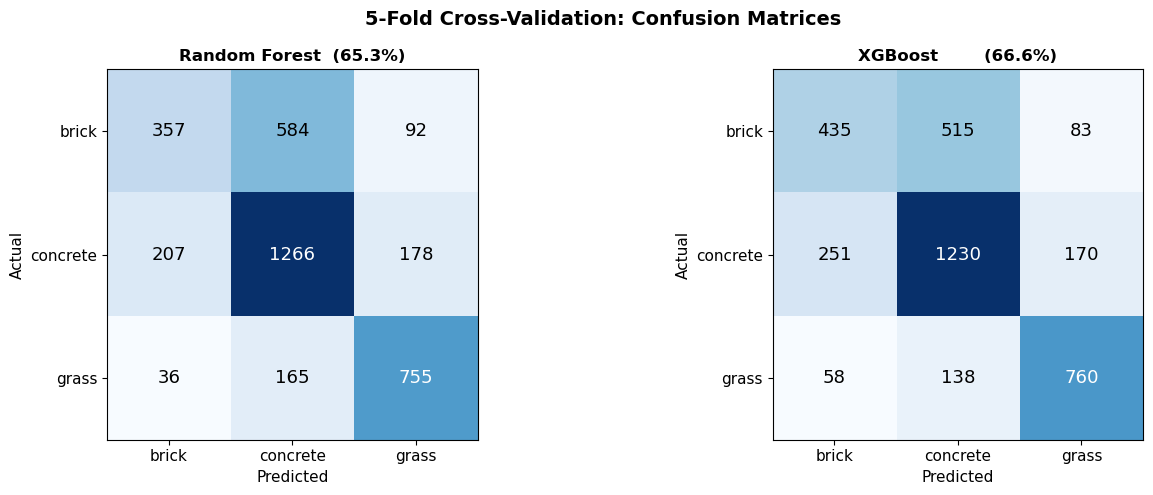


── Random Forest Classification Report ──────────────────
              precision    recall  f1-score   support

       brick      0.595     0.346     0.437      1033
    concrete      0.628     0.767     0.691      1651
       grass      0.737     0.790     0.762       956

    accuracy                          0.653      3640
   macro avg      0.653     0.634     0.630      3640
weighted avg      0.647     0.653     0.638      3640

── XGBoost Classification Report ────────────────────────
              precision    recall  f1-score   support

       brick      0.585     0.421     0.490      1033
    concrete      0.653     0.745     0.696      1651
       grass      0.750     0.795     0.772       956

    accuracy                          0.666      3640
   macro avg      0.663     0.654     0.653      3640
weighted avg      0.659     0.666     0.657      3640



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Cross-Validation: Confusion Matrices', fontsize=14, fontweight='bold')

for ax, y_cv, title in [
    (axes[0], y_cv_rf,         f'Random Forest  ({acc_rf*100:.1f}%)'),
    (axes[1], y_cv_xgb_labels, f'XGBoost        ({acc_xgb*100:.1f}%)')
]:
    cm = confusion_matrix(y_tr, y_cv, labels=classes)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Per-class report ──────────────────────────────────────────────────
print('\n── Random Forest Classification Report ──────────────────')
print(classification_report(y_tr, y_cv_rf, digits=3))

print('── XGBoost Classification Report ────────────────────────')
print(classification_report(y_tr, y_cv_xgb_labels, digits=3))

## 6. Accuracy Bar Chart + Feature Importance

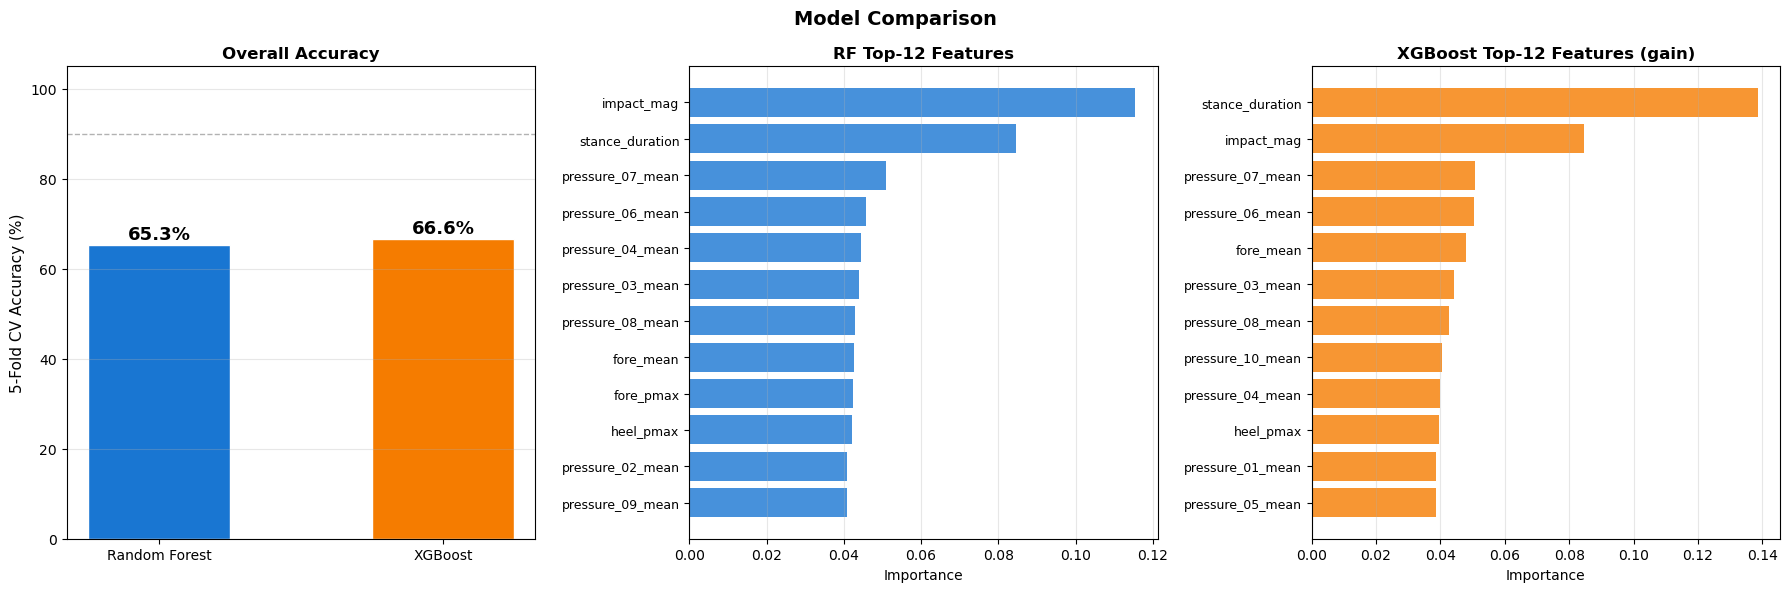

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# ── 6a. Overall accuracy bar ──────────────────────────────────────────
ax = axes[0]
models = ['Random Forest', 'XGBoost']
accs   = [acc_rf * 100, acc_xgb * 100]
colors = ['#1976D2', '#F57C00']
bars = ax.bar(models, accs, color=colors, width=0.5, edgecolor='white')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_ylim(0, 105); ax.set_ylabel('5-Fold CV Accuracy (%)', fontsize=11)
ax.set_title('Overall Accuracy', fontweight='bold')
ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.6, label='90% line')
ax.grid(axis='y', alpha=0.3)

# ── 6b. RF feature importance ─────────────────────────────────────────
ax = axes[1]
rf_imp = rf_pipe.named_steps['rf'].feature_importances_
top_n  = 12
top_idx_rf = np.argsort(rf_imp)[::-1][:top_n]
ax.barh(range(top_n), rf_imp[top_idx_rf][::-1], color='#1976D2', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([FEATURE_COLS[i] for i in top_idx_rf[::-1]], fontsize=9)
ax.set_xlabel('Importance', fontsize=10)
ax.set_title('RF Top-12 Features', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# ── 6c. XGBoost feature importance (gain) ─────────────────────────────
ax = axes[2]
xgb_imp = xgb_pipe.named_steps['xgb'].feature_importances_
top_idx_xgb = np.argsort(xgb_imp)[::-1][:top_n]
ax.barh(range(top_n), xgb_imp[top_idx_xgb][::-1], color='#F57C00', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([FEATURE_COLS[i] for i in top_idx_xgb[::-1]], fontsize=9)
ax.set_xlabel('Importance', fontsize=10)
ax.set_title('XGBoost Top-12 Features (gain)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Per-Surface F1 Comparison

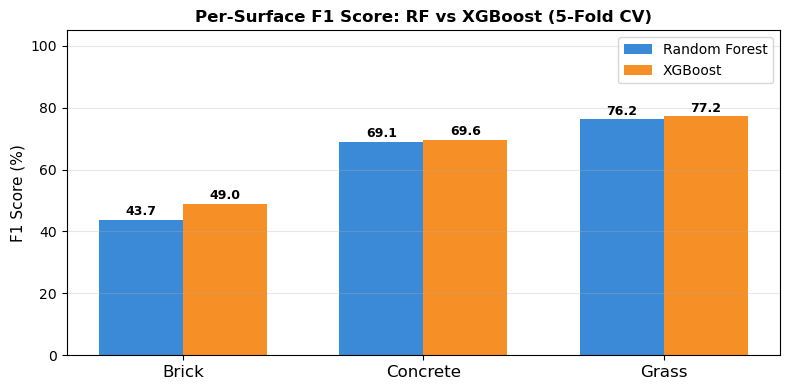

Per-surface F1 scores:
  brick       RF=43.7%  XGB=49.0%  ← XGB
  concrete    RF=69.1%  XGB=69.6%  ← XGB
  grass       RF=76.2%  XGB=77.2%  ← XGB


In [9]:
from sklearn.metrics import f1_score

f1_rf  = f1_score(y_tr, y_cv_rf,         labels=classes, average=None)
f1_xgb = f1_score(y_tr, y_cv_xgb_labels, labels=classes, average=None)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_rf  = ax.bar(x - width/2, f1_rf  * 100, width, label='Random Forest', color='#1976D2', alpha=0.85)
bars_xgb = ax.bar(x + width/2, f1_xgb * 100, width, label='XGBoost',       color='#F57C00', alpha=0.85)

for bars in [bars_rf, bars_xgb]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in classes], fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('Per-Surface F1 Score: RF vs XGBoost (5-Fold CV)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_surface_f1.png', bbox_inches='tight', dpi=150)
plt.show()

print('Per-surface F1 scores:')
for cls, r, x_ in zip(classes, f1_rf, f1_xgb):
    winner = '← XGB' if x_ > r else ('← RF' if r > x_ else '  tie')
    print(f'  {cls:10s}  RF={r*100:.1f}%  XGB={x_*100:.1f}%  {winner}')

## 8. Predict on New CSV

Set `NEW_CSV_PATH` below to any new recording. The best model (by CV accuracy) is used automatically.

In [10]:
# ── Set path to new recording ─────────────────────────────────────────
NEW_CSV_PATH = 'REC_20260520_200710.csv'   # ← change as needed

# ── Select best model ─────────────────────────────────────────────────
if acc_xgb >= acc_rf:
    best_pipe   = xgb_pipe
    best_name   = 'XGBoost'
    use_encoded = True
else:
    best_pipe   = rf_pipe
    best_name   = 'Random Forest'
    use_encoded = False

print(f'Using: {best_name} (CV acc={max(acc_rf,acc_xgb)*100:.1f}%)')

Using: XGBoost (CV acc=66.6%)


In [11]:
print(f'Loading: {NEW_CSV_PATH}')
new_raw = pd.read_csv(NEW_CSV_PATH, low_memory=False)
print(f'Rows: {len(new_raw)} | Soles: {sorted(new_raw["sole_id"].unique())}')

pred_frames = []
for sole_id, foot in [(1, 'right'), (2, 'left')]:
    sub = new_raw[new_raw['sole_id'] == sole_id].copy()

    # If the file has surface markers, use them; otherwise predict blind
    labelled = label_surface_segments(sub)
    if labelled is not None:
        df_proc = preprocess(labelled)
    else:
        df_proc = preprocess(sub)

    feats = extract_step_features(df_proc, surface_label='unknown', foot_label=foot)
    if len(feats):
        pred_frames.append(feats)
        print(f'  {foot}: {len(feats)} steps detected')

pred_df = pd.concat(pred_frames, ignore_index=True)
X_pred  = pred_df[FEATURE_COLS].fillna(0).values

if use_encoded:
    raw_preds = best_pipe.predict(X_pred)
    pred_df['predicted_surface'] = le.inverse_transform(raw_preds)
    proba = best_pipe.predict_proba(X_pred)
else:
    pred_df['predicted_surface'] = best_pipe.predict(X_pred)
    proba = best_pipe.predict_proba(X_pred)
    classes = best_pipe.classes_

for i, c in enumerate(classes):
    pred_df[f'prob_{c}'] = proba[:, i]
pred_df['max_confidence'] = proba.max(axis=1)

print(f'\nPrediction distribution ({best_name}):')
print(pred_df.groupby(['foot','predicted_surface']).size().unstack(fill_value=0))
print(f'\nMean confidence: {pred_df["max_confidence"].mean()*100:.1f}%')

Loading: REC_20260520_200710.csv
Rows: 46213 | Soles: [np.int64(1), np.int64(2)]
  right: 315 steps detected
  left: 315 steps detected

Prediction distribution (XGBoost):
predicted_surface  brick  concrete
foot                              
left                 160       155
right                162       153

Mean confidence: 84.5%


## 9. Prediction Visualisation

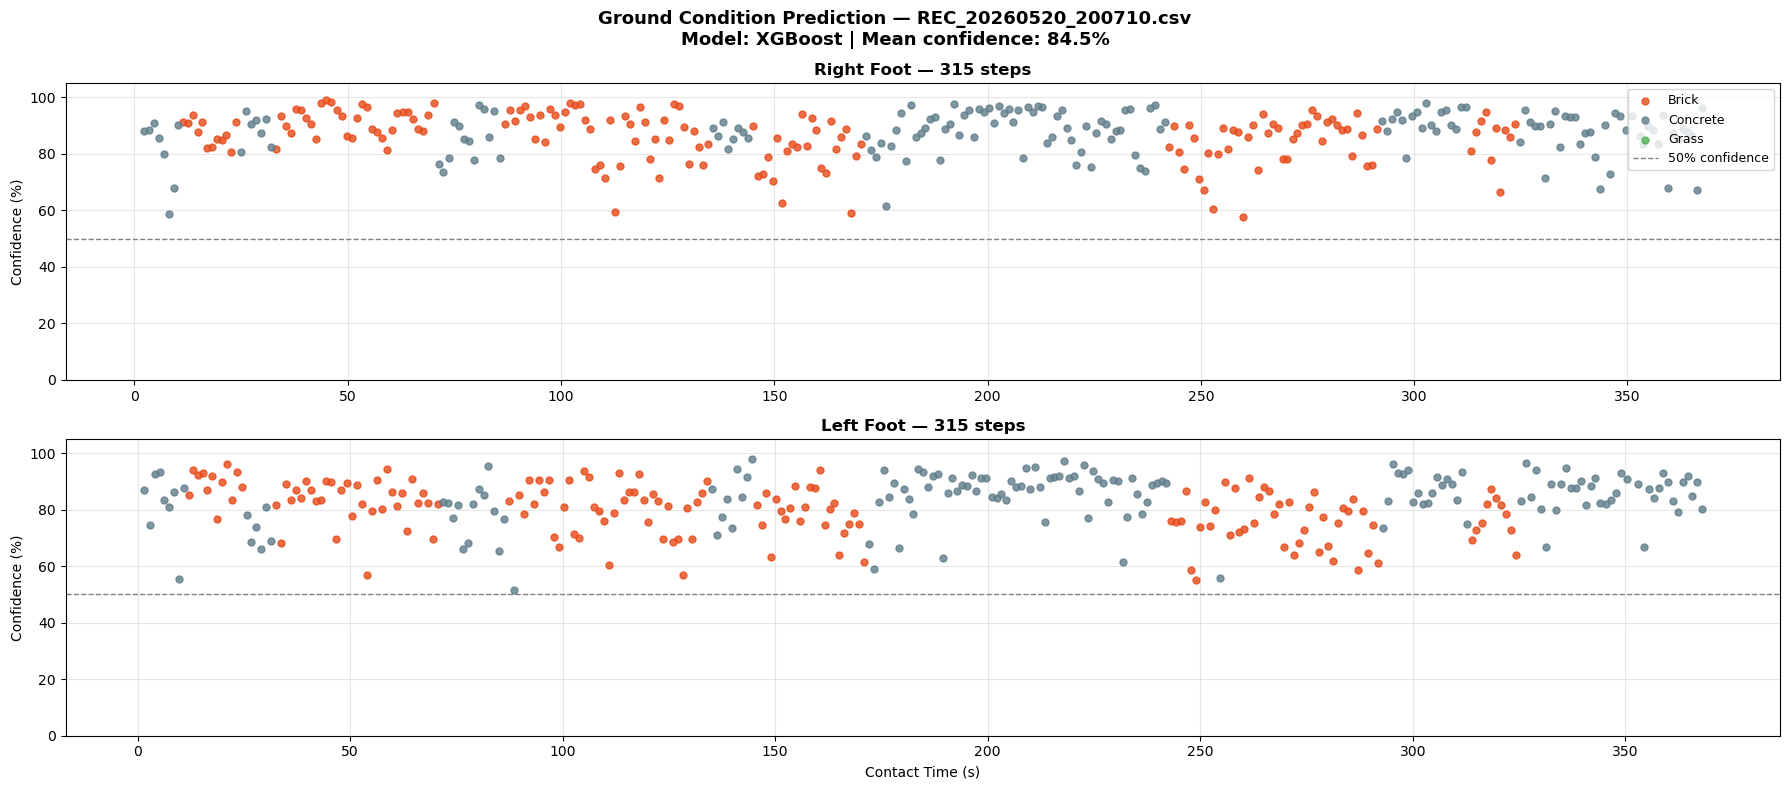

,foot,step_id,contact_time_sec,stance_duration,predicted_surface,max_confidence
0,right,0,2.192,1.264,concrete,0.880950
1,right,1,3.472,1.152,concrete,0.882852
2,right,2,4.640,1.088,concrete,0.909340
3,right,3,5.744,1.152,concrete,0.856166
4,right,4,6.912,1.104,concrete,0.799996
5,right,5,8.032,1.120,concrete,0.586541
6,right,6,9.168,1.120,concrete,0.678310
7,right,7,10.304,1.136,concrete,0.901974
8,right,8,11.456,1.120,brick,0.912693
9,right,9,12.592,1.104,brick,0.910248


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=False)
fig.suptitle(
    f'Ground Condition Prediction — {NEW_CSV_PATH}\n'
    f'Model: {best_name} | Mean confidence: {pred_df["max_confidence"].mean()*100:.1f}%',
    fontsize=13, fontweight='bold'
)

for ri, foot in enumerate(['right', 'left']):
    ax  = axes[ri]
    sub = pred_df[pred_df['foot'] == foot]
    for surf in classes:
        s = sub[sub['predicted_surface'] == surf]
        ax.scatter(s['contact_time_sec'], s['max_confidence']*100,
                   color=SURFACE_COLORS.get(surf, '#9E9E9E'),
                   s=25, alpha=0.8, label=surf.capitalize(), zorder=3)
    ax.axhline(50, color='gray', ls='--', lw=1, label='50% confidence')
    ax.set_ylabel('Confidence (%)')
    ax.set_ylim(0, 105)
    ax.set_title(f'{foot.capitalize()} Foot — {len(sub)} steps', fontweight='bold')
    ax.grid(alpha=0.3)
    if ri == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[1].set_xlabel('Contact Time (s)')
plt.tight_layout()
plt.savefig('prediction_confidence.png', bbox_inches='tight', dpi=150)
plt.show()

pred_df[['foot','step_id','contact_time_sec','stance_duration',
         'predicted_surface','max_confidence']].head(10)

## 10. Export Predictions to CSV

In [13]:
out_path = NEW_CSV_PATH.replace('.csv', f'_predictions_{best_name.replace(" ","_")}.csv')
pred_df[['foot','step_id','contact_time_sec','stance_duration',
         'impact_mag','loading_rate','predicted_surface','max_confidence']
       + [f'prob_{c}' for c in classes]
       ].to_csv(out_path, index=False)
print(f'Saved → {out_path}')

Saved → REC_20260520_200710_predictions_XGBoost.csv
